# Detecção de Anomalias em Processos Industriais via PCA
## Decomposição Espectral Aplicada ao Tennessee Eastman Process

---

| | |
|---|---|
| **Disciplina** | Fundamentos da Matemática Aplicada — ICMC/USP São Carlos |
| **Técnica** | Análise de Componentes Principais (PCA) via Decomposição Espectral |
| **Dataset** | Tennessee Eastman Process — Rieth et al. (2017), Harvard Dataverse |
| **Objetivo** | Detectar condições de falha usando apenas dados de operação normal |

---

### Grupo

| Nome | nº USP | Papel na Apresentação |
|---|---|---|
| Reynaldo Pereira Martins | 13490412 | **Parte I** — Introdução |
| Victor Zoratti Ferreira | 08006115 | **Parte II** — Metodologia |
| Eduardo Soares Zanutti | 10413611 | **Parte III** — Resultados |
| Fábio Luiz Souza Alves | 15084023 | **Parte IV** — Conclusões |

---

### Estrutura da Apresentação

| Parte | Apresentador | Conteúdo |
|---|---|---|
| **I — Introdução** | Reynaldo | Contexto industrial, o problema TEP, as 52 variáveis de processo |
| **II — Metodologia** | Victor | PCA, decomposição espectral $C = V\Lambda V^T$, índice SPE, interpretação geométrica |
| **III — Resultados** | Eduardo | Treino, calibração, detecção IDV(1) vs IDV(3), curva ROC, visualizações |
| **IV — Conclusões** | Fábio | Síntese, limitações do SPE, trabalhos futuros com autoencoders |

---

### Motivação

Processos industriais geram continuamente dados de dezenas de sensores. Identificar manualmente quando o processo saiu do estado normal é inviável em escala industrial.

Técnicas de **monitoramento estatístico de processos** baseadas em PCA permitem construir um detector automático que:
1. **Aprende** o padrão de operação normal a partir de dados históricos (decomposição espectral da covariância)
2. **Sinaliza** anomalias quando novas observações desviam desse padrão (erro de reconstrução SPE)

O fundamento matemático é a **decomposição espectral** da matriz de covariância — tema central desta disciplina.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, auc

# %matplotlib qt
%matplotlib inline

---
# Parte I — Introdução
## *Reynaldo Pereira Martins*

---

## 1. Dataset — Tennessee Eastman Process (TEP)

O TEP é um benchmark clássico em monitoramento de processos industriais proposto por Downs & Vogel (1993) e amplamente utilizado na literatura de detecção de anomalias.

**52 variáveis de processo:**

| Grupo | Variáveis | Tipo |
|---|---|---|
| Medições contínuas | XMEAS(1–22) | Pressão, temperatura, nível, vazão |
| Medições de composição | XMEAS(23–41) | Analisadores com delay de amostragem |
| Variáveis manipuladas | XMV(1–11) | Válvulas e fluxos de resfriamento |

**Escala do dataset:** 21 condições × 500 simulações × 500 amostras = **5.250.000 observações**

> **Protocolo de falha:** a falha é introduzida na **amostra 20** de cada simulação.  
> Amostras 1–20: pré-falha (processo ainda normal); amostras 21–500: pós-falha.

In [2]:
# TEP_dataset corresponde às amostras de TREINO (sem e com anomalia)
# 21 condições: faultNumber 0 (operação normal) e 1-20 (modos de falha)
# 500 simulações distintas por condição operacional
# Cada simulação: série temporal de 52 variáveis com 500 amostras
# Total: 21 × 500 × 500 = 5.250.000 amostras
# A falha é introduzida na amostra 20 (samples 1-20: pré-falha; 21-500: pós-falha)

import os
os.chdir('..')  # garante raiz do projeto

df_normal = pd.read_feather('data/processed/TEP_FaultFree_Training.feather')
df_faulty = pd.read_feather('data/processed/TEP_Faulty_Training.feather')
df = pd.concat([df_normal, df_faulty], ignore_index=True)
df

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5249995,20.0,500.0,496,0.23419,3655.3,4461.7,9.3448,27.008,42.481,2703.0,...,53.670,23.350,61.061,20.719,40.999,38.653,47.386,47.528,40.212,17.659
5249996,20.0,500.0,497,0.26704,3647.4,4540.2,9.3546,27.034,42.671,2704.7,...,54.650,26.362,60.020,20.263,41.579,33.624,47.536,47.647,41.199,18.741
5249997,20.0,500.0,498,0.26543,3630.3,4571.6,9.4089,27.129,42.470,2705.1,...,54.274,26.521,59.824,20.189,41.505,40.967,52.437,47.802,41.302,23.199
5249998,20.0,500.0,499,0.27671,3655.7,4498.9,9.3781,27.353,42.281,2705.8,...,53.506,26.781,62.818,20.453,40.208,40.957,47.628,48.086,40.510,15.932


In [3]:
# Como o dataset é muito grande, são selecionadas apenas as primeiras 10 simulações para cada condição operacional

df = df[(df['simulationRun']<=10)]
df

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,20.0,10.0,496,0.18775,3634.6,4506.5,9.4974,26.917,42.517,2717.8,...,53.406,18.343,60.887,19.151,39.765,44.321,48.896,50.081,40.901,16.381
349996,20.0,10.0,497,0.21604,3677.3,4561.3,9.3889,26.526,42.377,2720.0,...,54.472,21.633,63.214,19.248,39.146,40.060,43.945,49.827,41.338,19.881
349997,20.0,10.0,498,0.21859,3657.9,4571.8,9.2886,26.908,42.491,2717.5,...,54.346,21.382,61.266,18.908,39.062,39.445,44.736,49.662,40.485,18.311
349998,20.0,10.0,499,0.23267,3673.0,4522.1,9.3797,26.758,42.174,2716.7,...,53.854,22.349,61.046,18.399,40.159,43.239,45.333,49.107,41.646,16.398


---
# Parte II — Metodologia
## *Victor Zoratti Ferreira*

---

## 2. Metodologia — PCA via Decomposição Espectral

### Fundamento Matemático

Dada a matriz de dados normalizados $X \in \mathbb{R}^{n \times p}$, a matriz de covariância amostral $C = \frac{1}{n-1}X^TX$ admite **decomposição espectral**:

$$C = V \Lambda V^T$$

onde $V = [v_1, v_2, \ldots, v_p]$ são os **autovetores** (componentes principais) e $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_p)$ os **autovalores**, com $\lambda_1 \geq \cdots \geq \lambda_p \geq 0$.

### Seleção do Subespaço de Operação Normal

Retendo os $k$ maiores autovetores $V_k = [v_1, \ldots, v_k]$, capturamos a fração $\alpha$ de variância:

$$\sum_{i=1}^{k} \lambda_i \;\Big/\; \sum_{i=1}^{p} \lambda_i \;\geq\; \alpha$$

O hiperparâmetro $\alpha$ controla o tamanho do subespaço: maior $\alpha$ → mais componentes → maior sensibilidade dentro do subespaço.

### Índice de Detecção — Squared Prediction Error (SPE)

Para uma nova amostra $x$, o SPE mede o **erro de reconstrução** ao projetar no subespaço $\mathcal{S}_k$:

$$\text{SPE}(x) = \|x - \hat{x}\|^2, \quad \hat{x} = V_k V_k^T x$$

$$\begin{cases} \text{SPE}(x) \leq \delta^2 & \Rightarrow \text{operação normal} \\ \text{SPE}(x) > \delta^2 & \Rightarrow \text{anomalia detectada} \end{cases}$$

O limiar $\delta^2$ é estimado empiricamente no conjunto de validação (dados normais não utilizados no treino).

### Interpretação Geométrica da Transformação

Pelo Teorema Espectral, a transformação $C\mathbf{x} = V\Lambda V^T\mathbf{x}$ se decompõe em **três operações sucessivas**:

$$C\mathbf{x} = \underbrace{V}_{\text{(3) reconstrução}} \Big(\; \underbrace{\Lambda}_{\text{(2) escala}} \;\underbrace{(V^T\mathbf{x})}_{\text{(1) projeção}} \;\Big)$$

| Passo | Operação | Significado |
|---|---|---|
| (1) $V^T\mathbf{x}$ | **Projeção** | Coordenadas de $\mathbf{x}$ na base dos autovetores |
| (2) $\Lambda(\cdots)$ | **Escala** | Cada coordenada é multiplicada pelo autovalor $\lambda_i$ |
| (3) $V(\cdots)$ | **Reconstrução** | Volta ao espaço original na base canônica |

O SPE explora exatamente essa decomposição: ao **zerar as coordenadas** $k+1, \ldots, p$ antes da reconstrução, o erro $\|x - \hat{x}\|^2$ captura tudo que **não foi explicado** pelo subespaço $\mathcal{S}_k = \text{span}(v_1, \ldots, v_k)$.

> *Referência: Nonato, L.G. — "Álgebra Linear: Autovalores, Autovetores e Teorema Espectral", ICMC/USP São Carlos*

In [4]:
class PCA_anomaly_detection():

    def __init__(self, fracao_variancia_explicada):
        self.fracao_variancia_explicada = fracao_variancia_explicada
        self.pca = PCA()

    def train(self, X):
        self.mu_train = X.mean(axis=0)
        self.std_train = X.std(axis=0)
        X = np.array((X - self.mu_train) / self.std_train)
        self.pca.fit(X)
        self.variancia_explicada_acumulada = np.cumsum(self.pca.explained_variance_ratio_)
        if self.fracao_variancia_explicada == 1:
            self.n_componentes = len(self.variancia_explicada_acumulada)
        else:
            self.n_componentes = np.argmax(self.variancia_explicada_acumulada >= self.fracao_variancia_explicada) + 1
        T = self.pca.transform(X)
        T[:, self.n_componentes:] = 0
        X_rec = self.pca.inverse_transform(T)
        self.SPE_train = np.sum((X - X_rec) ** 2, axis=1)
        self.SPE_train[self.SPE_train < 1e-10] = 0.0

    def set_threshold(self, X_validation, percentil=99.99):
        '''Calcula o threshold a partir de dados de VALIDAÇÃO (não vistos no treino).
        Prática recomendada: evita threshold otimista calculado nos próprios dados de treino.'''
        SPE_val = self.predict(X_validation)
        self.percentil = percentil
        self.threshold_SPE = np.percentile(SPE_val, percentil)
        self.SPE_validation = SPE_val
        return self.threshold_SPE

    def predict(self, X):
        X = np.array((X - self.mu_train) / self.std_train)
        T = self.pca.transform(X)
        T[:, self.n_componentes:] = 0
        X_rec = self.pca.inverse_transform(T)
        SPE = np.sum((X - X_rec) ** 2, axis=1)
        SPE[SPE < 1e-10] = 0.0
        return SPE

    def plot_variancia_explicada(self):
        fig = plt.figure(figsize=(15, 5))
        plt.bar(np.arange(1, self.pca.n_components_ + 1), self.pca.explained_variance_ratio_,
                alpha=0.3, label='Variância por componente')
        plt.plot(np.arange(1, self.pca.n_components_ + 1), self.variancia_explicada_acumulada,
                 marker='o', markersize=5, markerfacecolor='none', label='Variância acumulada')
        plt.axhline(y=self.fracao_variancia_explicada, linestyle='--', color='black', alpha=0.7,
                    label=f'Fração alvo: {self.fracao_variancia_explicada}')
        plt.axvline(x=self.n_componentes, linestyle='--', color='red', linewidth=1.5,
                    label=f'Nº componentes selecionadas: {self.n_componentes}')
        plt.title('Variância Explicada Acumulada — PCA')
        plt.xticks(np.arange(1, self.pca.n_components_ + 1))
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_distribuicao_SPE(self):
        '''Plota a distribuição do SPE do conjunto de validação (ou treino se validação não disponível).'''
        SPE = self.SPE_validation if hasattr(self, 'SPE_validation') else self.SPE_train
        label = 'Validação' if hasattr(self, 'SPE_validation') else 'Treino'
        fig = plt.figure(figsize=(15, 5))
        plt.hist(SPE, bins=40, density=True, alpha=0.4, color='steelblue', label=f'Histograma ({label})')
        kde = gaussian_kde(SPE)
        x = np.linspace(SPE.min(), SPE.max(), 300)
        plt.plot(x, kde(x), color='steelblue', linewidth=2, label='KDE')
        plt.axvline(x=self.threshold_SPE, linestyle='--', color='red', linewidth=1.5,
                    label=f'Threshold ({self.percentil}% — {label}): {self.threshold_SPE:.4f}')
        plt.xlabel('SPE')
        plt.yticks([])
        plt.title(f'Distribuição do SPE — Conjunto de {label}')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

---
# Parte III — Resultados
## *Eduardo Soares Zanutti*

---

## 3. Treino e Calibração do Modelo

### Estratégia de Divisão dos Dados

Seguimos a metodologia de monitoramento estatístico de processos com três conjuntos disjuntos:

| Conjunto | Condição | Simulações | Finalidade |
|---|---|---|---|
| **Treino** | Normal (`faultNumber = 0`) | 1 | Estimar $V$ e $\Lambda$ via PCA |
| **Validação** | Normal (`faultNumber = 0`) | 2–4 | Calibrar o threshold $\delta^2$ (percentil 99,99%) |
| **Teste** | Falha IDV(1) e IDV(3) | 1 | Avaliar capacidade de detecção |

> **Por que calibrar na validação?**  
> Se o threshold fosse extraído dos próprios dados de treino, o modelo aprenderia o nível de ruído da amostra específica usada no treino, resultando em um limiar artificialmente otimista. Dados de validação independentes garantem uma estimativa conservadora e representativa da operação normal real.

In [5]:
# SPLIT TREINO / VALIDAÇÃO / TESTE
# Treino:    condição normal, simulação 1
# Validação: condição normal, simulações 2-4  → usado para calibrar o threshold
# Teste:     condições de falha, simulação 1  → avaliação de detecção

df_train      = df[(df['faultNumber'] == 0) & (df['simulationRun'] == 1)].iloc[:, 3:]
df_validation = df[(df['faultNumber'] == 0) & (df['simulationRun'].between(2, 4))].iloc[:, 3:]

print(f'Treino:    {len(df_train):,} amostras')
print(f'Validação: {len(df_validation):,} amostras')

Treino:    500 amostras
Validação: 1,500 amostras


In [17]:
# Treinamento — 90% de variância explicada (padrão da literatura para TEP)
pca = PCA_anomaly_detection(fracao_variancia_explicada=0.9)
pca.train(df_train)

# Threshold calibrado no conjunto de VALIDAÇÃO — dados normais não usados no treino
threshold_SPE = pca.set_threshold(df_validation, percentil=99.99)

print(f'Componentes principais selecionadas: {pca.n_componentes}')
print(f'Threshold SPE (percentil {pca.percentil}% — validação): {threshold_SPE:.4f}')

Componentes principais selecionadas: 30
Threshold SPE (percentil 99.99% — validação): 25.4457


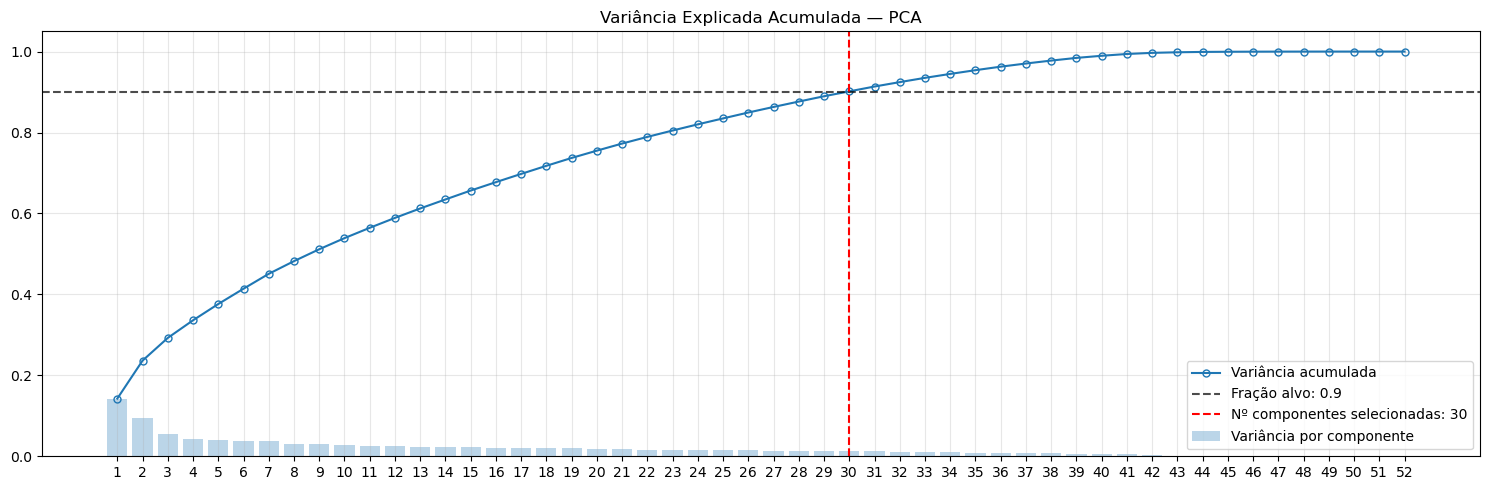

In [7]:
pca.plot_variancia_explicada()

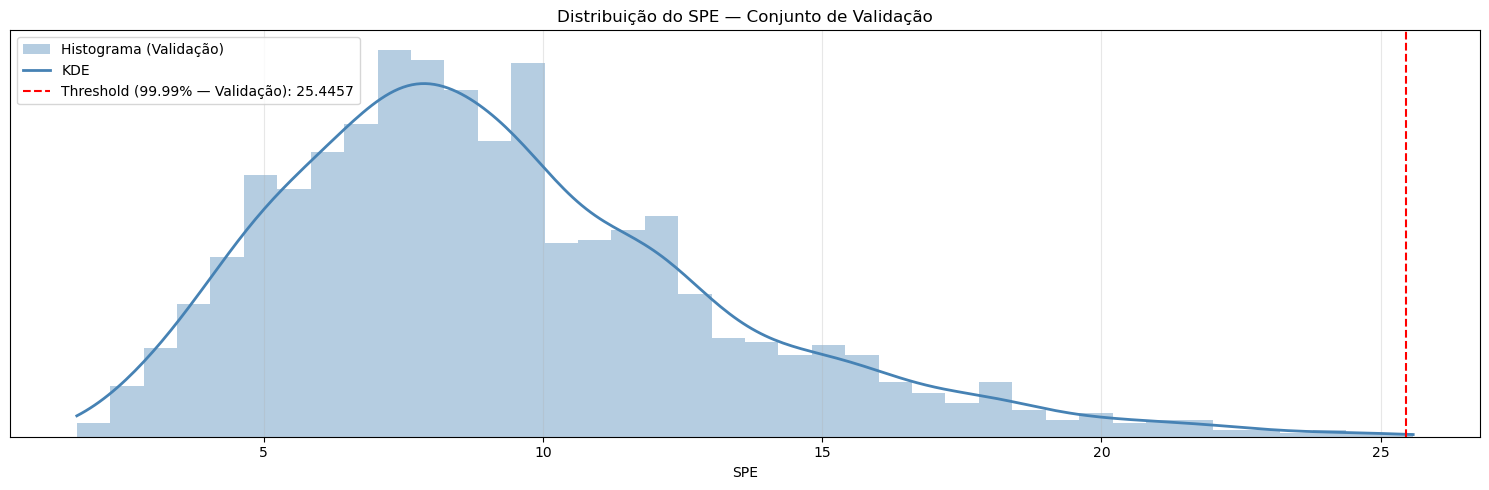

In [8]:
pca.plot_distribuicao_SPE()

---
## 4. Resultados — Detecção de Anomalias por SPE

Aplicamos o detector treinado às condições de falha. As **amostras 1–20 são pré-falha** (o processo ainda opera normalmente) e **amostras 21–500 são pós-falha**.

Avaliamos duas falhas com comportamentos contrastantes:

| Falha | Descrição | Hipótese |
|---|---|---|
| **IDV(1)** | Variação em degrau na razão de alimentação A/C | Alta FDR — falha gera resíduo fora do subespaço normal |
| **IDV(3)** | Variação em degrau na temperatura de alimentação D | Baixa FDR — limitação conhecida do SPE para este tipo de falha |

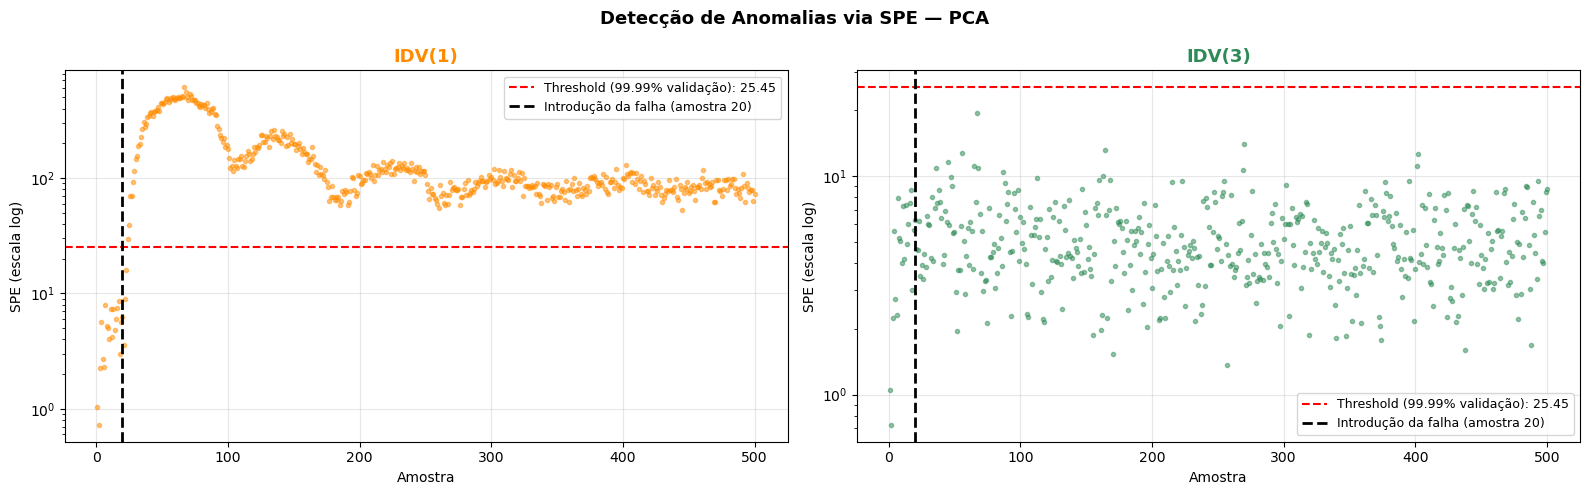

In [9]:
# Detecção de anomalias: IDV(1) — falha detectável vs IDV(3) — falha difícil
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fault_number, cor in zip(axes, [1, 3], ['darkorange', 'seagreen']):
    df_test_fault = df[(df['faultNumber'] == fault_number) & (df['simulationRun'] == 1)].iloc[:, 3:]
    SPE_test = pca.predict(df_test_fault)
    samples = np.arange(1, len(SPE_test) + 1)

    ax.semilogy(samples, SPE_test, '.', alpha=0.5, color=cor)
    ax.axhline(threshold_SPE, ls='--', c='r', linewidth=1.5,
               label=f'Threshold (99.99% validação): {threshold_SPE:.2f}')
    ax.axvline(x=20, color='k', linestyle='--', linewidth=2, label='Introdução da falha (amostra 20)')
    ax.set_title(f'IDV({fault_number})', fontsize=13, fontweight='bold', color=cor)
    ax.set_ylabel('SPE (escala log)')
    ax.set_xlabel('Amostra')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Detecção de Anomalias via SPE — PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Taxa de Detecção (FDR) — fração de amostras pós-falha corretamente detectadas
print(f'Threshold SPE (percentil {pca.percentil}% — validação): {threshold_SPE:.4f}\n')

for fault_number in [1, 3]:
    df_fault = df[(df['faultNumber'] == fault_number) & (df['simulationRun'] == 1)].iloc[:, 3:]
    SPE = pca.predict(df_fault)

    fdr  = np.mean(SPE[20:] > threshold_SPE)   # amostras pós-falha detectadas
    far  = np.mean(SPE[:20] > threshold_SPE)   # amostras pré-falha (falso alarme)

    print(f'IDV({fault_number}):')
    print(f'  Taxa de Detecção (FDR): {100*fdr:.1f}%  ({int(fdr*(500-20))} de {500-20} amostras pós-falha)')
    print(f'  Taxa de Falso Alarme :  {100*far:.1f}%  ({int(far*20)} de 20 amostras pré-falha)\n')

Threshold SPE (percentil 99.99% — validação): 25.4457

IDV(1):
  Taxa de Detecção (FDR): 99.4%  (477 de 480 amostras pós-falha)
  Taxa de Falso Alarme :  0.0%  (0 de 20 amostras pré-falha)

IDV(3):
  Taxa de Detecção (FDR): 0.0%  (0 de 480 amostras pós-falha)
  Taxa de Falso Alarme :  0.0%  (0 de 20 amostras pré-falha)



In [11]:
# seleciona o conjunto de teste formado por todas as amostras das simulações com faultNumber entre 1 e 20
df_test = df[(df['faultNumber']>=1)].iloc[:,3:]

# Todas as amostras do conjunto de teste com sample maior que 20 são classificadas como 1 (situação de falha) e todas as amostras com sample menor ou igual a 20 são classificadas como 0 (situação sem falha)
classificacao_test = (df[(df['faultNumber']>=1)].loc[:,'sample'] > 20).astype(int)

---
## 5. Análise de Sensibilidade — Curva ROC

Avaliamos o efeito do número de componentes principais — parametrizado pela **fração de variância explicada** $\alpha$ — no desempenho de detecção sobre as 20 falhas do dataset.

A **curva ROC** plota a Sensibilidade (TPR) versus Taxa de Falso Alarme (FPR) varrendo todos os possíveis thresholds. A **AUC** resume a qualidade discriminativa do score SPE bruto:

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

- AUC = 1,0 → detector perfeito  
- AUC = 0,5 → equivalente ao acaso  

> O threshold de cada modelo é calibrado na validação antes de avaliar. A curva ROC usa o score SPE bruto (sem threshold fixo) varrendo toda a curva — por isso avalia todas as 20 falhas, não só IDV(1) e IDV(3).

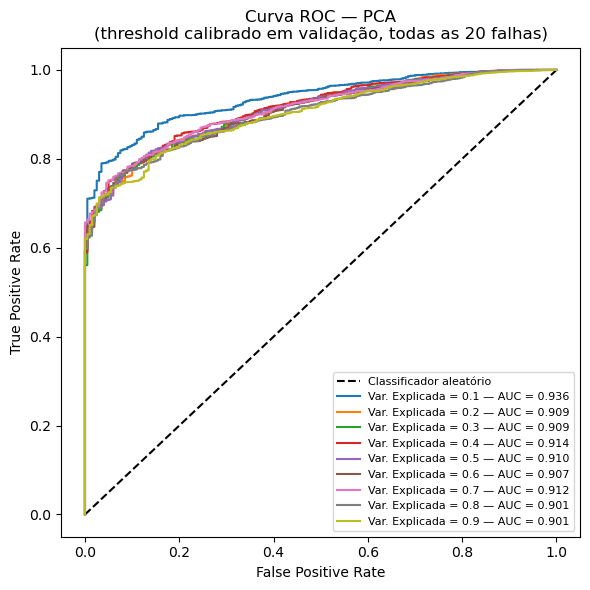

In [12]:
# Curva ROC — variando a fração de variância explicada
# Threshold calibrado em validação para cada modelo

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório')

for fracao in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    pca_roc = PCA_anomaly_detection(fracao_variancia_explicada=fracao)
    pca_roc.train(df_train)
    pca_roc.set_threshold(df_validation, percentil=99.99)
    SPE_test = pca_roc.predict(df_test)

    fpr, tpr, _ = roc_curve(classificacao_test, SPE_test)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Var. Explicada = {fracao} — AUC = {roc_auc:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — PCA\n(threshold calibrado em validação, todas as 20 falhas)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Análise Exploratória — Séries Temporais e Espaço PCA

Visualizamos o comportamento do processo nas três condições (normal, IDV(1) e IDV(3)) de duas formas complementares:

1. **Séries temporais das variáveis de processo** — mostra diretamente como os sensores reagem à falha no domínio do tempo
2. **Projeção no espaço PCA (PC1 × PC2)** — revela geometricamente por que o SPE detecta IDV(1) mas falha em IDV(3)
3. **Visualização 3D interativa** — combina eixo temporal com os dois primeiros componentes, mostrando a trajetória do processo no subespaço PCA

> A linha/plano vermelho marca a **amostra 20** — momento de introdução da falha.

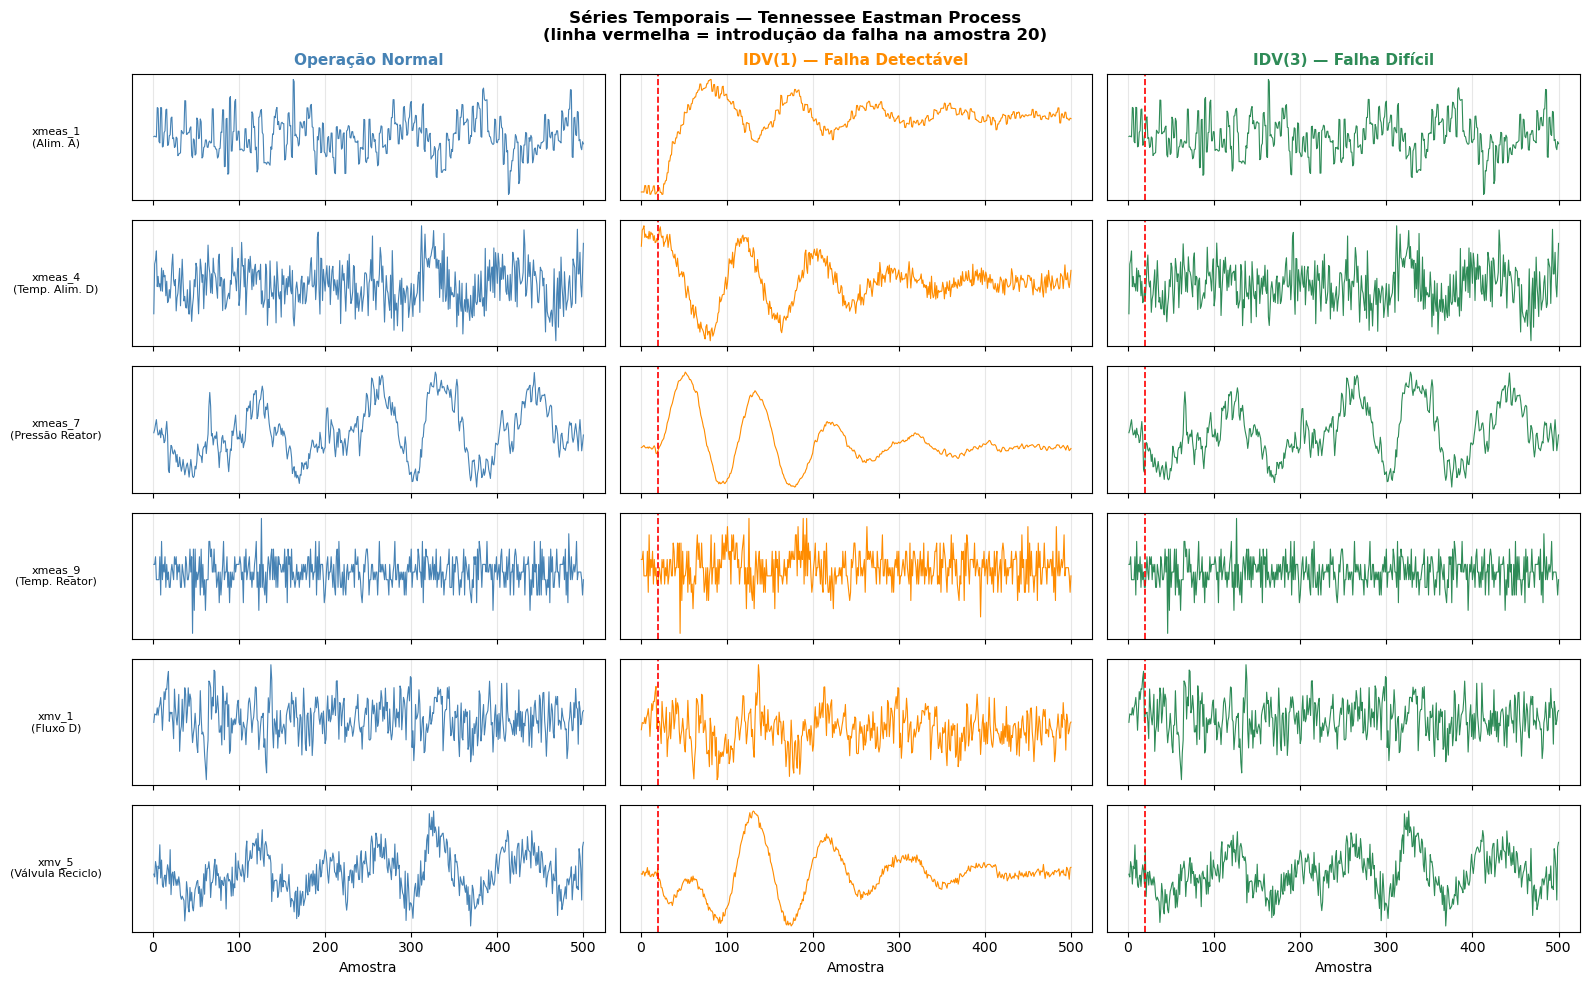

In [13]:
sim = 1  # simulação utilizada na visualização

# Variáveis selecionadas para ilustrar o problema
variaveis = ['xmeas_1', 'xmeas_4', 'xmeas_7', 'xmeas_9', 'xmv_1', 'xmv_5']
titulos   = ['xmeas_1\n(Alim. A)',
             'xmeas_4\n(Temp. Alim. D)',
             'xmeas_7\n(Pressão Reator)',
             'xmeas_9\n(Temp. Reator)',
             'xmv_1\n(Fluxo D)',
             'xmv_5\n(Válvula Reciclo)']

df_sim_normal = df[(df['faultNumber'] == 0) & (df['simulationRun'] == sim)]
df_sim_fault1 = df[(df['faultNumber'] == 1) & (df['simulationRun'] == sim)]
df_sim_fault3 = df[(df['faultNumber'] == 3) & (df['simulationRun'] == sim)]

samples = np.arange(1, 501)

fig, axes = plt.subplots(len(variaveis), 3, figsize=(16, 10), sharex=True)

cenarios = [
    (df_sim_normal, 'steelblue',  'Operação Normal'),
    (df_sim_fault1, 'darkorange', 'IDV(1) — Falha Detectável'),
    (df_sim_fault3, 'seagreen',   'IDV(3) — Falha Difícil'),
]

for i, (var, titulo) in enumerate(zip(variaveis, titulos)):
    for j, (df_j, cor, rotulo) in enumerate(cenarios):
        axes[i, j].plot(samples, df_j[var].values, linewidth=0.8, color=cor)
        if j > 0:
            axes[i, j].axvline(x=20, color='red', linestyle='--', linewidth=1.2)
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(rotulo, fontsize=11, fontweight='bold', color=cor)
    axes[i, 0].set_ylabel(titulo, fontsize=8, rotation=0, labelpad=55, va='center')

for ax in axes[-1, :]:
    ax.set_xlabel('Amostra', fontsize=10)

plt.suptitle(
    'Séries Temporais — Tennessee Eastman Process\n'
    '(linha vermelha = introdução da falha na amostra 20)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Espaço das Componentes Principais — PC1 × PC2

A decomposição espectral define um subespaço onde a operação normal vive. Projetando os dados nas duas primeiras componentes principais — as direções de maior variância segundo $C = V\Lambda V^T$ — podemos visualizar diretamente essa região.

- A nuvem azul mostra onde a operação normal se concentra nesse plano.
- **IDV(1)**: os pontos pós-falha migram para **fora** dessa nuvem → o erro de reconstrução SPE cresce → falha detectada.
- **IDV(3)**: os pontos pós-falha permanecem **misturados** à nuvem normal → o SPE, que só mede a distância ao subespaço $\mathcal{S}_k$, é insensível a esse desvio.

Essa é a limitação geométrica central do método: o SPE captura apenas desvios que saem do subespaço $\mathcal{S}_k$, não desvios que ocorrem dentro dele.


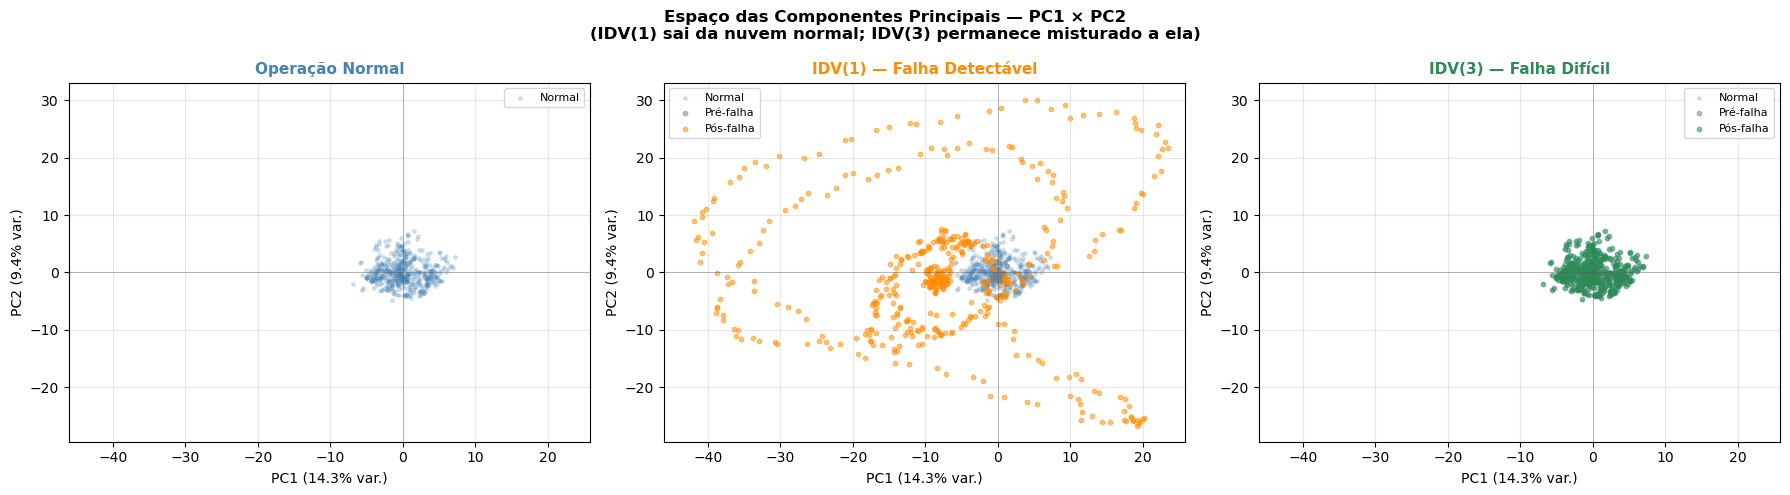

In [14]:
def projetar_pc(df, modelo):
    X = np.array((df.values - modelo.mu_train.values) / modelo.std_train.values)
    return modelo.pca.transform(X)

# Garante as mesmas 52 features usadas no treino do PCA (remove faultNumber/simulationRun/sample)
feature_cols = pca.mu_train.index
df_sim_normal = df_sim_normal[feature_cols]
df_sim_fault1 = df_sim_fault1[feature_cols]
df_sim_fault3 = df_sim_fault3[feature_cols]

T_normal = projetar_pc(df_sim_normal, pca)
T_fault1 = projetar_pc(df_sim_fault1, pca)
T_fault3 = projetar_pc(df_sim_fault3, pca)

# Limites globais para comparação direta entre os painéis
all_pc1 = np.concatenate([T_normal[:, 0], T_fault1[:, 0], T_fault3[:, 0]])
all_pc2 = np.concatenate([T_normal[:, 1], T_fault1[:, 1], T_fault3[:, 1]])
xlim = (all_pc1.min() * 1.1, all_pc1.max() * 1.1)
ylim = (all_pc2.min() * 1.1, all_pc2.max() * 1.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cenarios = [
    (T_normal, None,        'steelblue',  'Operação Normal'),
    (T_fault1, T_fault1,    'darkorange', 'IDV(1) — Falha Detectável'),
    (T_fault3, T_fault3,    'seagreen',   'IDV(3) — Falha Difícil'),
]

for ax, (T, T_fault, cor, titulo) in zip(axes, cenarios):
    ax.scatter(T_normal[:, 0], T_normal[:, 1], c='steelblue', alpha=0.2, s=6, label='Normal')

    if T_fault is not None:
        ax.scatter(T_fault[:20, 0],  T_fault[:20, 1],  c='gray', alpha=0.5, s=10, label='Pré-falha')
        ax.scatter(T_fault[20:, 0],  T_fault[20:, 1],  c=cor,    alpha=0.5, s=10, label='Pós-falha')

    ax.axhline(0, color='k', linewidth=0.4, alpha=0.4)
    ax.axvline(0, color='k', linewidth=0.4, alpha=0.4)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(f'PC1 ({100*pca.pca.explained_variance_ratio_[0]:.1f}% var.)', fontsize=10)
    ax.set_ylabel(f'PC2 ({100*pca.pca.explained_variance_ratio_[1]:.1f}% var.)', fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold', color=cor)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Espaço das Componentes Principais — PC1 × PC2\n'
             '(IDV(1) sai da nuvem normal; IDV(3) permanece misturado a ela)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
import plotly.graph_objects as go

samples_arr = np.arange(1, 501)

# Limites para eixos PC1/PC2
pc1_lim = [min(T_normal[:, 0].min(), T_fault1[:, 0].min(), T_fault3[:, 0].min()) * 1.4,
           max(T_normal[:, 0].max(), T_fault1[:, 0].max(), T_fault3[:, 0].max()) * 1.4]
pc2_lim = [min(T_normal[:, 1].min(), T_fault1[:, 1].min(), T_fault3[:, 1].min()) * 1.4,
           max(T_normal[:, 1].max(), T_fault1[:, 1].max(), T_fault3[:, 1].max()) * 1.4]

# Plano x=20 — marca introdução da falha com tempo no eixo horizontal
plane_x = np.full((2, 2), 20.0)
plane_y = np.array([[pc2_lim[0], pc2_lim[1]], [pc2_lim[0], pc2_lim[1]]])
plane_z = np.array([[pc1_lim[0], pc1_lim[0]], [pc1_lim[1], pc1_lim[1]]])

fig = go.Figure()

# Operação normal (azul escuro para maior contraste com o verde)
fig.add_trace(go.Scatter3d(
    x=samples_arr, y=T_normal[:, 1], z=T_normal[:, 0],
    mode='markers',
    marker=dict(size=2.5, color="#46049C", opacity=0.75),
    name='Operação Normal'
))

# Pré-falha IDV(1) e IDV(3) — cinza
fig.add_trace(go.Scatter3d(
    x=samples_arr[:20], y=T_fault1[:20, 1], z=T_fault1[:20, 0],
    mode='markers',
    marker=dict(size=5, color='#888888', opacity=0.85),
    name='Pré-falha (amostras 1-20)'
))
fig.add_trace(go.Scatter3d(
    x=samples_arr[:20], y=T_fault3[:20, 1], z=T_fault3[:20, 0],
    mode='markers',
    marker=dict(size=5, color='#888888', opacity=0.85),
    showlegend=False, name='Pré-falha IDV3'
))

# Pós-falha IDV(1) — laranja
fig.add_trace(go.Scatter3d(
    x=samples_arr[20:], y=T_fault1[20:, 1], z=T_fault1[20:, 0],
    mode='markers',
    marker=dict(size=3, color='#FF8C00', opacity=0.75),
    name='IDV(1) — Pós-falha (detectável)'
))

# Pós-falha IDV(3) — verde
fig.add_trace(go.Scatter3d(
    x=samples_arr[20:], y=T_fault3[20:, 1], z=T_fault3[20:, 0],
    mode='markers',
    marker=dict(size=3, color='#2E8B57', opacity=0.75),
    name='IDV(3) — Pós-falha (difícil de detectar)'
))

# Plano da falha (x=20)
fig.add_trace(go.Surface(
    x=plane_x, y=plane_y, z=plane_z,
    colorscale=[[0, 'red'], [1, 'red']],
    opacity=0.25,
    showscale=False,
    name='Introdução da falha (amostra 20)'
))

axis_style = dict(
    showgrid=True,
    gridcolor='rgba(80,80,80,0.35)',
    gridwidth=1,
    showbackground=True,
    showline=True,
    linecolor='rgba(0,0,0,0.5)',
    linewidth=2,
    tickfont=dict(size=10),
    titlefont=dict(size=12),
)

# Remove chave inválida para eixos 3D em versões recentes do Plotly
axis_style_clean = {k: v for k, v in axis_style.items() if k != "titlefont"}

fig.update_layout(
    title=dict(
        text='Trajetória Temporal no Espaço PCA — Tempo × PC2 × PC1<br>'
             '<sup>Plano vermelho = introdução da falha (amostra 20) | '
             'Azul = normal | Laranja = IDV(1) | Verde = IDV(3)</sup>',
        x=0.5,
        font=dict(size=15)
    ),
    scene=dict(
        xaxis=dict(
            title=dict(text='Amostra (tempo)', font=dict(size=12)),
            backgroundcolor='rgba(255,245,230,0.9)',
            **axis_style_clean
        ),
        yaxis=dict(
            title=dict(text='PC2', font=dict(size=12)),
            backgroundcolor='rgba(230,255,235,0.9)',
            **axis_style_clean
        ),
        zaxis=dict(
            title=dict(text='PC1', font=dict(size=12)),
            backgroundcolor='rgba(230,235,255,0.9)',
            **axis_style_clean
        ),
        camera=dict(eye=dict(x=0., y=-2., z=0)),
        aspectmode='auto'
    ),
    height=700,
    legend=dict(
        x=0.01, y=0.97,
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='rgba(0,0,0,0.3)',
        borderwidth=1,
        font=dict(size=12)
    ),
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

---
# Parte IV — Conclusões
## *Fábio Luiz Souza Alves*

---

## 7. Conclusões

### Resumo dos Resultados

| Falha | Descrição | Detecção | Explicação Geométrica |
|---|---|---|---|
| **IDV(1)** | Variação degrau razão A/C | **Alta FDR** | Pontos pós-falha saem da nuvem normal no plano PC1×PC2 — alto SPE |
| **IDV(3)** | Variação degrau temp. alim. D | **Baixa FDR** | Pontos pós-falha permanecem misturados à nuvem normal — SPE insensível |

### Interpretação via Decomposição Espectral

A visualização no espaço PC1 × PC2 torna a limitação do método **geometricamente evidente**:

- **IDV(1)**: a falha desloca o processo para fora do subespaço $\mathcal{S}_k = \text{span}(V_k)$ → $\text{SPE}(x) = \|x - V_k V_k^T x\|^2 \gg \delta^2$ → **detecção**
- **IDV(3)**: a falha permanece dentro de $\mathcal{S}_k$ → $\text{SPE}(x) \approx 0$ → **sem detecção**

### Limitação Fundamental e Trabalhos Futuros

O SPE é cego a qualquer falha que se manifeste **dentro** do subespaço principal — e o PCA, sendo uma técnica linear, assume que a estrutura de correlação normal do processo é bem descrita por um subespaço linear. Falhas como IDV(3), cujo efeito se confunde com a variabilidade normal nesse subespaço, expõem esse limite estrutural.

Spina et al. (2024) comparam diferentes arquiteturas de *autoencoders* (AE, Deep AE, VAE, DAE, Deep DAE) com o PCA no mesmo benchmark TEP, usando a mesma lógica de erro de reconstrução (SPE) e área sob a curva ROC (AUC) como métrica de comparação. Para a Falha 3 — a mesma falha difícil analisada aqui — o PCA obtém o menor AUC entre os métodos comparados (0,718), enquanto os autoencoders alcançam valores mais altos (até 0,763), por conseguirem capturar relações **não lineares** entre as variáveis que o subespaço linear do PCA não representa.

Isso aponta um caminho natural de extensão deste trabalho: substituir a projeção linear $V_k V_k^T$ por um *autoencoder* não linear, mantendo a mesma lógica de treino semi-supervisionado (apenas dados normais) e o mesmo índice SPE como estatística de monitoramento, mas com um encoder/decoder não linear capaz de representar desvios que hoje ficam "escondidos" dentro do subespaço principal do PCA.

### Mensagens-Chave

1. **PCA não é só redução de dimensionalidade** — é uma ferramenta de monitoramento estatístico fundamentada na decomposição espectral
2. **O método é semi-supervisionado:** treina apenas em dados normais e detecta qualquer desvio desse padrão
3. **O SPE tem uma limitação estrutural clara:** falhas confinadas ao subespaço principal (como IDV(3)) não são detectadas — a linearidade do PCA é a causa raiz
4. **Extensões não lineares (autoencoders) são o caminho natural** para cobrir esse tipo de falha, como evidenciado por Spina et al. (2024) no mesmo benchmark TEP
5. **Custo computacional baixo e alta interpretabilidade:** viável para monitoramento industrial em tempo real
